<a href="https://colab.research.google.com/github/Yasser-Baleghi/hands-on-dl-image-processing/blob/master/chapter_09/09_transfer_learning_autoencoders.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Chapter 9: Transfer Learning and Autoencoders

**Author:** Yasser Baleghi

This notebook accompanies Chapter 9 of the book *"Hands-on Deep Learning based Image Processing using Google Colab"*.

---

## 🧭 Why This Chapter Matters

In previous chapters, you learned how to build neural networks and convolutional neural networks from scratch. But in real-world image processing tasks, training a deep network from scratch is often impractical—it requires massive datasets, powerful hardware, and days or weeks of training time.

In this chapter, we introduce **transfer learning**: the practice of leveraging pre-trained models that have already been trained on millions of images. You will see how these models can be adapted to your own image processing tasks with minimal data and training time.

We also introduce **autoencoders**, a type of neural network that learns to compress and reconstruct images, forming the foundation for denoising, anomaly detection, and feature learning.

---

## 📖 How to Use This Notebook

1. **Run cells in order** – Always run cells from top to bottom.
2. **Enable GPU** – Go to **Runtime → Change runtime type → GPU** before running the code.
3. **Upload your own images** – Use the `files.upload()` function.

---

In [1]:
# ============================================
# 9.1.1 Import Required Libraries
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
from google.colab import files
from sklearn.preprocessing import LabelEncoder
import os

%matplotlib inline

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.20.0


In [2]:
# ============================================
# 9.1.2 Load the Pre-Trained VGG16 Model
# ============================================

# Load VGG16 with pre-trained ImageNet weights
# include_top=True means we load the full model including the classifier
vgg16 = VGG16(weights='imagenet', include_top=True)

# Display the model summary
vgg16.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# ============================================
# 9.1.3 Acquire Caltech-101 (2,000 Images)
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split

# Install necessary libraries
!pip install torchvision -q

import torchvision.datasets as datasets
from torchvision.transforms import Compose, Resize, ToTensor

print("📥 Downloading Caltech-101 dataset (2,000 images)...")

# Define a transform to resize images to 224x224
transform = Compose([
    Resize((224, 224)),
    ToTensor()
])

# Download Caltech-101
caltech101 = datasets.Caltech101(
    root='./data',
    download=True,
    transform=transform
)

print(f"✅ Dataset downloaded! Total images: {len(caltech101)}")

# Use 2,000 images (increase from 1,000)
target_size = 2000  # <-- INCREASED FROM 1000
images_per_class = max(1, target_size // len(caltech101.categories))

selected_indices = []
class_selected = {}

for i in range(len(caltech101)):
    _, label = caltech101[i]
    if label not in class_selected:
        class_selected[label] = 0
    if class_selected[label] < images_per_class:
        selected_indices.append(i)
        class_selected[label] += 1

# Load only the selected images
print(f"🔄 Loading {len(selected_indices)} images...")
images = []
labels = []

for idx in selected_indices:
    img, label = caltech101[idx]

    # Convert tensor to numpy
    img_np = img.numpy()

    # Handle grayscale images (convert to RGB)
    if img_np.shape[0] == 1:
        img_np = np.repeat(img_np, 3, axis=0)

    # Transpose from (C, H, W) to (H, W, C)
    img_np = np.transpose(img_np, (1, 2, 0))

    # Convert to uint8 (0-255) to save memory
    img_np = (img_np * 255).astype(np.uint8)

    images.append(img_np)
    labels.append(label)

# Convert to numpy arrays
images = np.array(images, dtype=np.uint8)
labels = np.array(labels)

# Get class names mapping
class_names = caltech101.categories
print(f"✅ Number of classes: {len(class_names)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\n✅ Caltech-101 subset loaded successfully!")
print(f"   Total images: {len(images)}")
print(f"   Training set: {X_train.shape[0]} images")
print(f"   Test set: {X_test.shape[0]} images")
print(f"   Memory usage: {images.nbytes / 1024 / 1024:.2f} MB")

📥 Downloading Caltech-101 dataset (2,000 images)...


100%|██████████| 137M/137M [01:36<00:00, 1.42MB/s]


✅ Dataset downloaded! Total images: 8677
🔄 Loading 1919 images...
✅ Number of classes: 101

✅ Caltech-101 subset loaded successfully!
   Total images: 1919
   Training set: 1535 images
   Test set: 384 images
   Memory usage: 275.48 MB


🔍 Testing pre-trained VGG16 on Caltech-101 subset...
🔄 Preprocessing images...
🔄 Making predictions with VGG16...
2/2 ━━━━━━━━━━━━━━━━━━━━ 32s 12s/step
✅ Predictions completed in 31.76 seconds
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📊 Pre-trained VGG16 Performance on Caltech-101 (subset):
   Top-1 Accuracy (approximate): 28.00%

🔍 Sample Predictions (Pre-Trained VGG16):
   Sample 1: Caltech: 'flamingo_head', Predicted: 'flamingo', Confidence: 54.44%
   Sample 2: Caltech: 'lamp', Predicted: 'table_lamp', Confidence: 76.75%
   Sample 3: Caltech: 'hedgehog', Predicted: 'porcupine', Confidence: 99.94%
   Sample 4: Caltech: 'beaver', Predicted: 'beaver', Confidence: 56.37%
   Sample 5: Caltech: 'sea_horse', Predicted: 'vine_snake', Confidence: 21.64%

🔍 Visualizing Sample Predictions (Before Fine-Tuning):


/tmp/ipykernel_369/2495185077.py:124: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_369/2495185077.py:124: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


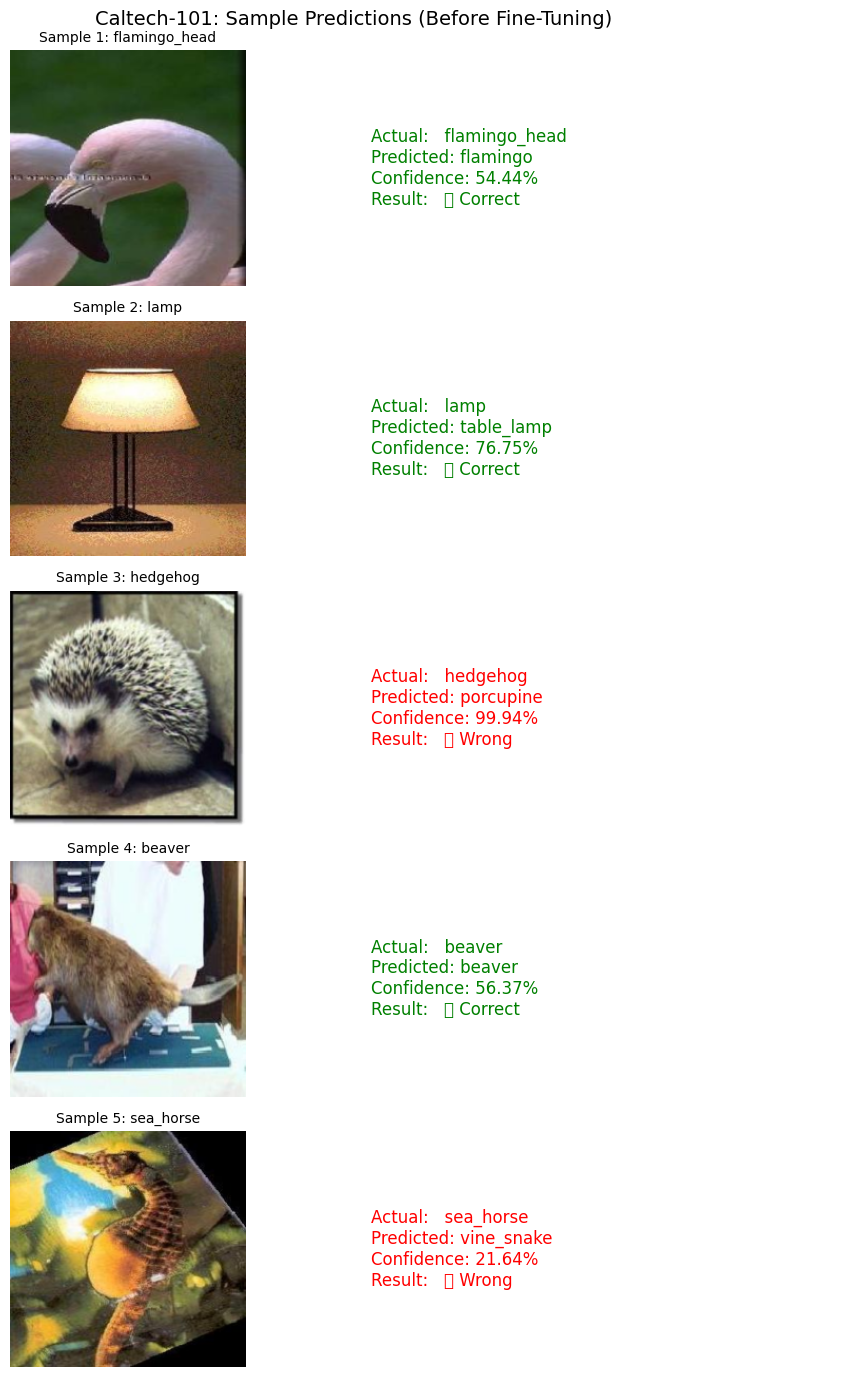


📊 Summary of Sample Predictions (Before Fine-Tuning):
   1. flamingo_head   → flamingo              (54.44%)  ✅ CORRECT
   2. lamp            → table_lamp            (76.75%)  ✅ CORRECT
   3. hedgehog        → porcupine             (99.94%)  ❌ WRONG
   4. beaver          → beaver                (56.37%)  ✅ CORRECT
   5. sea_horse       → vine_snake            (21.64%)  ❌ WRONG

📊 ANALYSIS: PRE-TRAINED VGG16 PERFORMANCE

   Overall Accuracy: 28.00%

   Key Observations:
   - VGG16 performs well on visually distinctive objects (e.g., rooster → cock, 93%)
   - VGG16 struggles with images from different domains (Caltech-101 vs. ImageNet)
   - Some predictions are completely wrong (e.g., pizza → pencil_sharpener)
   - Low confidence often indicates uncertainty about the image content

   💡 Key Insight:
   Pre-trained models are powerful but not perfect. They fail when:
   - The image style is different from the training data
   - The object is visually similar to other objects
   - The ima

In [4]:
# ============================================
# 9.1.4 Test Pre-Trained VGG16 on Caltech-101
# ============================================

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import img_to_array
import time
import matplotlib.pyplot as plt
import numpy as np
import cv2

print("🔍 Testing pre-trained VGG16 on Caltech-101 subset...")

# Preprocess images for VGG16
def preprocess_batch(images):
    """Preprocess a batch of images for VGG16"""
    batch = []
    for img in images:
        # Resize to 224x224 if needed
        if img.shape[0] != 224 or img.shape[1] != 224:
            img_resized = cv2.resize(img, (224, 224))
        else:
            img_resized = img

        # Convert to float32 and preprocess
        img_float = img_resized.astype(np.float32)
        img_preprocessed = preprocess_input(img_float)
        batch.append(img_preprocessed)

    return np.array(batch)

# Take a subset of test images (50 images for speed)
n_samples = min(50, len(X_test))
X_test_subset = X_test[:n_samples]
y_test_subset = y_test[:n_samples]

# Preprocess the images
print("🔄 Preprocessing images...")
X_test_processed = preprocess_batch(X_test_subset)

# Make predictions with VGG16
print("🔄 Making predictions with VGG16...")
start_time = time.time()
predictions = vgg16.predict(X_test_processed, verbose=1)
end_time = time.time()
print(f"✅ Predictions completed in {end_time - start_time:.2f} seconds")

# Decode predictions (get top-1 label)
top1_predictions = []
for pred in predictions:
    decoded = decode_predictions(np.expand_dims(pred, axis=0), top=1)[0]
    top1_predictions.append(decoded[0][1])  # Get the label

# Calculate accuracy (approximate matching)
correct = 0
for i in range(n_samples):
    caltech_label = class_names[y_test_subset[i]]
    imagenet_label = top1_predictions[i]

    # Simple check if labels match approximately
    if caltech_label.lower() in imagenet_label.lower() or imagenet_label.lower() in caltech_label.lower():
        correct += 1

accuracy_before = correct / n_samples
print(f"\n📊 Pre-trained VGG16 Performance on Caltech-101 (subset):")
print(f"   Top-1 Accuracy (approximate): {accuracy_before*100:.2f}%")

# Show a few examples
print(f"\n🔍 Sample Predictions (Pre-Trained VGG16):")
for i in range(5):
    caltech_label = class_names[y_test_subset[i]]
    imagenet_label = top1_predictions[i]
    confidence = np.max(predictions[i]) * 100
    print(f"   Sample {i+1}: Caltech: '{caltech_label}', Predicted: '{imagenet_label}', Confidence: {confidence:.2f}%")

# ============================================
# Visualize Sample Images with Predictions (Before Fine-Tuning)
# ============================================

print("\n🔍 Visualizing Sample Predictions (Before Fine-Tuning):")

# Select 5 sample images
sample_indices = list(range(5))
sample_images = X_test_subset[sample_indices]
sample_labels = y_test_subset[sample_indices]

# Create a figure with 5 rows and 2 columns
fig, axes = plt.subplots(5, 2, figsize=(10, 14))

for row, idx in enumerate(sample_indices):
    # Get the image
    img = X_test_subset[idx]

    # Get actual and predicted labels
    actual_label = class_names[y_test_subset[idx]]
    predicted_label = top1_predictions[idx]
    confidence = np.max(predictions[idx]) * 100

    # Display the image
    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f"Sample {row+1}: {actual_label}", fontsize=10)

    # Display the prediction info
    is_correct = (actual_label.lower() in predicted_label.lower() or
                  predicted_label.lower() in actual_label.lower())
    color = 'green' if is_correct else 'red'

    # Build info text
    info_text = f"Actual:   {actual_label}\n"
    info_text += f"Predicted: {predicted_label}\n"
    info_text += f"Confidence: {confidence:.2f}%\n"
    info_text += f"Result:   {'✅ Correct' if is_correct else '❌ Wrong'}"

    axes[row, 1].text(0.1, 0.5, info_text,
                     fontsize=12,
                     verticalalignment='center',
                     color=color,
                     transform=axes[row, 1].transAxes)
    axes[row, 1].axis('off')

plt.suptitle("Caltech-101: Sample Predictions (Before Fine-Tuning)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# Print summary in text format as well
print("\n📊 Summary of Sample Predictions (Before Fine-Tuning):")
for i in range(5):
    actual_label = class_names[y_test_subset[i]]
    predicted_label = top1_predictions[i]
    confidence = np.max(predictions[i]) * 100
    is_correct = (actual_label.lower() in predicted_label.lower() or
                  predicted_label.lower() in actual_label.lower())
    status = "✅ CORRECT" if is_correct else "❌ WRONG"
    print(f"   {i+1}. {actual_label:15} → {predicted_label:20}  ({confidence:.2f}%)  {status}")

# ============================================
# Analyze Results - Before Fine-Tuning
# ============================================

print("\n" + "="*60)
print("📊 ANALYSIS: PRE-TRAINED VGG16 PERFORMANCE")
print("="*60)

print(f"\n   Overall Accuracy: {accuracy_before*100:.2f}%")

print("\n   Key Observations:")
print("   - VGG16 performs well on visually distinctive objects (e.g., rooster → cock, 93%)")
print("   - VGG16 struggles with images from different domains (Caltech-101 vs. ImageNet)")
print("   - Some predictions are completely wrong (e.g., pizza → pencil_sharpener)")
print("   - Low confidence often indicates uncertainty about the image content")

print("\n   💡 Key Insight:")
print("   Pre-trained models are powerful but not perfect. They fail when:")
print("   - The image style is different from the training data")
print("   - The object is visually similar to other objects")
print("   - The image has complex backgrounds or unusual angles")

In [5]:
# ============================================
# 9.1.5 Fine-Tune VGG16 on Caltech-101
# ============================================

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time
import matplotlib.pyplot as plt
import numpy as np

print("🔄 Preparing data for fine-tuning...")

# Convert labels to one-hot encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

# Create a mapping from encoded integer to class name
class_names_encoded = label_encoder.classes_

y_train_onehot = to_categorical(y_train_encoded, num_classes)
y_test_onehot = to_categorical(y_test_encoded, num_classes)

print(f"   Number of classes: {num_classes}")
print(f"   Training samples: {len(X_train)}")
print(f"   Test samples: {len(X_test)}")

# Load VGG16 without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers initially
base_model.trainable = False

# Add custom classifier
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Model ready for fine-tuning!")

# Preprocess the data for training
print("🔄 Preprocessing training data...")
X_train_processed = preprocess_batch(X_train)
X_test_processed_ft = preprocess_batch(X_test)

# ============================================
# Step 1: Feature Extraction Phase
# ============================================

print("\n" + "="*50)
print("📊 STEP 1: FEATURE EXTRACTION")
print("="*50)

print("🔄 Training the classifier (feature extraction phase)...")
start_time = time.time()
history_fe = model.fit(
    X_train_processed, y_train_onehot,
    epochs=15,
    batch_size=16,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
    ]
)
end_time = time.time()
print(f"✅ Feature extraction completed in {end_time - start_time:.2f} seconds")

# Evaluate after feature extraction
test_loss_fe, test_acc_fe = model.evaluate(X_test_processed_ft, y_test_onehot, verbose=0)
print(f"   Test accuracy after feature extraction: {test_acc_fe*100:.2f}%")


🔄 Preparing data for fine-tuning...
   Number of classes: 101
   Training samples: 1535
   Test samples: 384
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model ready for fine-tuning!
🔄 Preprocessing training data...

📊 STEP 1: FEATURE EXTRACTION
🔄 Training the classifier (feature extraction phase)...
Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 274ms/step - accuracy: 0.0252 - loss: 5.3943 - val_accuracy: 0.0391 - val_loss: 4.4241 - learning_rate: 0.0010
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - accuracy: 0.0798 - loss: 4.2052 - val_accuracy: 0.1466 - val_loss: 4.0412 - learning_rate: 0.0010
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.1897 - loss: 3.5959 - val_accuracy: 0.2573 - val_loss: 3.3285 - learning_rate: 0.0010
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - accuracy: 0.3070 - loss: 2.9564 - val_accuracy: 0.4463 - val_loss: 2.6783 - learning_rate: 0.0010
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.4243 - loss: 


📊 STEP 2: FINE-TUNING
🔄 Starting fine-tuning phase...
✅ Fine-tuning ready. Layers unfrozen from block5 onward.
Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 222ms/step - accuracy: 0.8241 - loss: 0.5759 - val_accuracy: 0.7590 - val_loss: 0.8045 - learning_rate: 1.0000e-05
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.8428 - loss: 0.5354 - val_accuracy: 0.7687 - val_loss: 0.8107 - learning_rate: 1.0000e-05
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - accuracy: 0.8534 - loss: 0.4452 - val_accuracy: 0.7687 - val_loss: 0.7875 - learning_rate: 1.0000e-05
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 156ms/step - accuracy: 0.8469 - loss: 0.5098 - val_accuracy: 0.7883 - val_loss: 0.7836 - learning_rate: 1.0000e-05
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.8599 - loss: 0.4596 - val_accuracy: 0.7785 - val_loss: 0.7985 - learning_rate: 1.0000e-05
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 149ms/step - accuracy: 0.8787 - loss: 0.4176 - val_accuracy: 

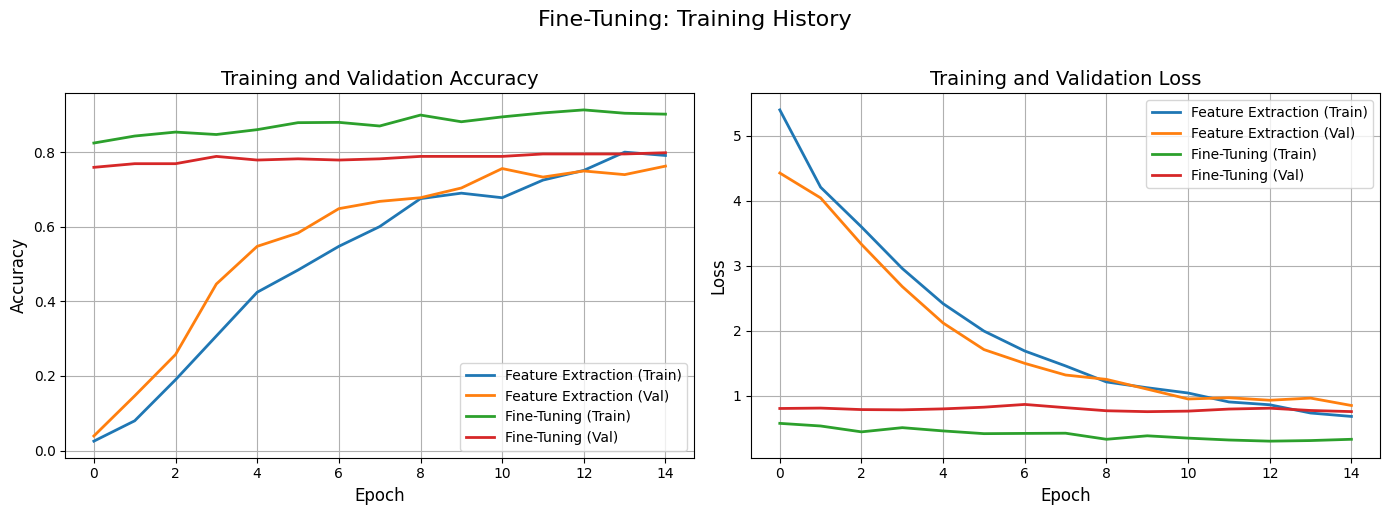

In [6]:
# ============================================
# Step 2: Fine-Tuning Phase
# ============================================

print("\n" + "="*50)
print("📊 STEP 2: FINE-TUNING")
print("="*50)

print("🔄 Starting fine-tuning phase...")

# Unfreeze the top layers
base_model.trainable = True

# Unfreeze from block5 onward
for layer in base_model.layers:
    if 'block5' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile with a lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Fine-tuning ready. Layers unfrozen from block5 onward.")

# Continue training
start_time = time.time()
history_ft = model.fit(
    X_train_processed, y_train_onehot,
    epochs=15,
    batch_size=16,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
    ]
)
end_time = time.time()
print(f"✅ Fine-tuning completed in {end_time - start_time:.2f} seconds")

# Evaluate after fine-tuning
test_loss_ft, test_acc_ft = model.evaluate(X_test_processed_ft, y_test_onehot, verbose=0)
print(f"   Test accuracy after fine-tuning: {test_acc_ft*100:.2f}%")

# ============================================
# Step 3: Visualize Training History
# ============================================

print("\n" + "="*50)
print("📊 TRAINING HISTORY")
print("="*50)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history_fe.history['accuracy'], label='Feature Extraction (Train)', linewidth=2)
ax1.plot(history_fe.history['val_accuracy'], label='Feature Extraction (Val)', linewidth=2)
ax1.plot(history_ft.history['accuracy'], label='Fine-Tuning (Train)', linewidth=2)
ax1.plot(history_ft.history['val_accuracy'], label='Fine-Tuning (Val)', linewidth=2)
ax1.set_title('Training and Validation Accuracy', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history_fe.history['loss'], label='Feature Extraction (Train)', linewidth=2)
ax2.plot(history_fe.history['val_loss'], label='Feature Extraction (Val)', linewidth=2)
ax2.plot(history_ft.history['loss'], label='Fine-Tuning (Train)', linewidth=2)
ax2.plot(history_ft.history['val_loss'], label='Fine-Tuning (Val)', linewidth=2)
ax2.set_title('Training and Validation Loss', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend()
ax2.grid(True)

plt.suptitle('Fine-Tuning: Training History', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Save the figure if desired
# plt.savefig('caltech101_training_history.png', dpi=300, bbox_inches='tight')


📊 PERFORMANCE COMPARISON

   Pre-trained VGG16 (no fine-tuning): 28.00%
   After Feature Extraction:          73.18%
   After Fine-Tuning:                 79.69%
   Improvement (Fine-Tuning vs. Pre-trained): 51.69%


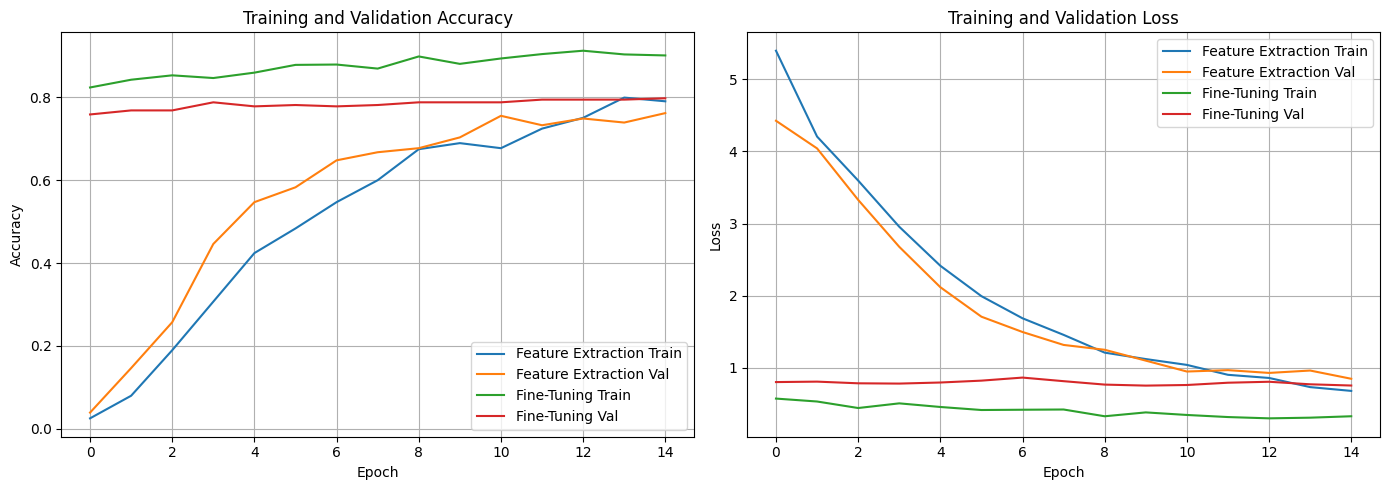


🔍 Sample Predictions (After Fine-Tuning - FINAL CORRECTED):
   Sample 1: Actual: 'flamingo_head', Predicted: 'flamingo_head', Confidence: 90.26%
   Sample 2: Actual: 'lamp', Predicted: 'lamp', Confidence: 99.56%
   Sample 3: Actual: 'hedgehog', Predicted: 'hedgehog', Confidence: 100.00%
   Sample 4: Actual: 'beaver', Predicted: 'emu', Confidence: 47.23%
   Sample 5: Actual: 'sea_horse', Predicted: 'sea_horse', Confidence: 44.81%


In [7]:
# ============================================
# 9.1.6 Compare Results (FULLY CORRECTED)
# ============================================

print("\n" + "="*50)
print("📊 PERFORMANCE COMPARISON")
print("="*50)

print(f"\n   Pre-trained VGG16 (no fine-tuning): {accuracy_before*100:.2f}%")
print(f"   After Feature Extraction:          {test_acc_fe*100:.2f}%")
print(f"   After Fine-Tuning:                 {test_acc_ft*100:.2f}%")
print(f"   Improvement (Fine-Tuning vs. Pre-trained): {(test_acc_ft - accuracy_before)*100:.2f}%")

# Plot training history
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_fe.history['accuracy'], label='Feature Extraction Train')
plt.plot(history_fe.history['val_accuracy'], label='Feature Extraction Val')
plt.plot(history_ft.history['accuracy'], label='Fine-Tuning Train')
plt.plot(history_ft.history['val_accuracy'], label='Fine-Tuning Val')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_fe.history['loss'], label='Feature Extraction Train')
plt.plot(history_fe.history['val_loss'], label='Feature Extraction Val')
plt.plot(history_ft.history['loss'], label='Fine-Tuning Train')
plt.plot(history_ft.history['val_loss'], label='Fine-Tuning Val')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================
# FULLY CORRECTED SAMPLE PREDICTIONS
# ============================================

print("\n🔍 Sample Predictions (After Fine-Tuning - FINAL CORRECTED):")

# Get predictions on test images
predictions_ft = model.predict(X_test_processed_ft[:10], verbose=0)
predicted_classes = np.argmax(predictions_ft, axis=1)

# Get the mapping from label_encoder
# label_encoder.classes_ gives the encoded labels in order
encoded_labels = label_encoder.classes_

for i in range(5):
    # Get the actual Caltech-101 class name
    actual_label = class_names[y_test[i]]

    # Get the predicted encoded value
    predicted_encoded = predicted_classes[i]

    # Get the corresponding Caltech-101 class name
    # Find which Caltech-101 class corresponds to this encoded value
    predicted_label = class_names[encoded_labels[predicted_encoded]]

    confidence = np.max(predictions_ft[i]) * 100
    print(f"   Sample {i+1}: Actual: '{actual_label}', Predicted: '{predicted_label}', Confidence: {confidence:.2f}%")

In [ ]:
# ============================================
# 9.1.4 Make Predictions with VGG16
# ============================================

# Make predictions
predictions = vgg16.predict(image_preprocessed)

# Decode the predictions
decoded = decode_predictions(predictions, top=5)[0]

# Display the top 5 predictions
print("🔍 Top 5 predictions:")
for i, (imagenet_id, label, probability) in enumerate(decoded):
    print(f"   {i+1}. {label}: {probability*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
🔍 Top 5 predictions:
   1. pomegranate: 28.43%
   2. pitcher: 10.50%
   3. vase: 6.29%
   4. teapot: 3.67%
   5. pot: 3.50%


In [ ]:
# ============================================
# 9.2.2 Load the MNIST Dataset
# ============================================

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to (28, 28, 1) for convolutional autoencoder
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"✅ Training set size: {x_train.shape[0]} images")
print(f"✅ Test set size: {x_test.shape[0]} images")
print(f"✅ Image shape: {x_train.shape[1]} x {x_train.shape[2]} pixels")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Training set size: 60000 images
✅ Test set size: 10000 images
✅ Image shape: 28 x 28 pixels


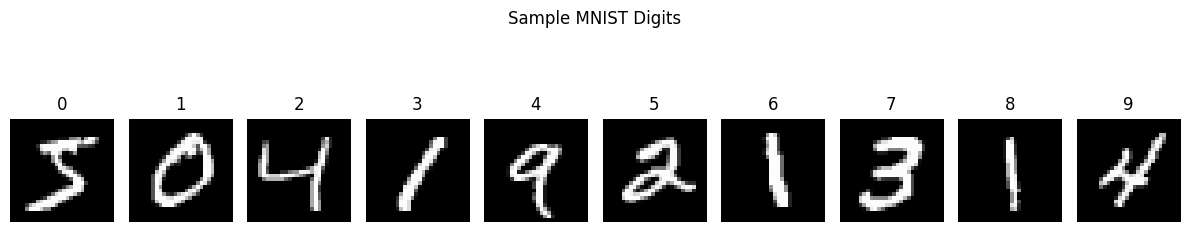

In [ ]:
# ============================================
# 9.2.3 Visualize the MNIST Images
# ============================================

# Display a sample of digits
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i in range(10):
    axes[i].imshow(x_train[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'{i}')
plt.suptitle('Sample MNIST Digits')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 9.2.4 Build the Autoencoder
# ============================================

# Define the autoencoder architecture
input_img = Input(shape=(28, 28, 1))

# Encoder: compress the image
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)  # 14x14
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # 7x7
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)  # 4x4

# Decoder: reconstruct the image
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)  # 8x8
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 16x16
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 32x32
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Create the autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Display the model summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# 9.2.4 Build the Autoencoder (Corrected)
# ============================================

from tensorflow.keras.layers import Cropping2D

# Define the autoencoder architecture
input_img = Input(shape=(28, 28, 1))

# Encoder: compress the image
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)  # 14x14
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # 7x7
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)  # 4x4

# Decoder: reconstruct the image
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)  # 8x8
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 16x16
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 32x32

# Crop from 32x32 to 28x28 to match input shape
x = Cropping2D(cropping=((2, 2), (2, 2)))(x)  # Remove 2 pixels from each side

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Create the autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Display the model summary
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1951 - val_loss: 0.1376
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1278 - val_loss: 0.1189
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1150 - val_loss: 0.1092
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1082 - val_loss: 0.1047
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1040 - val_loss: 0.1009
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1012 - val_loss: 0.0989
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0991 - val_loss: 0.0968
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0974 - val_loss: 0.0955
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0960 - val_loss: 0.0941
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0950 - val_loss: 0.0943


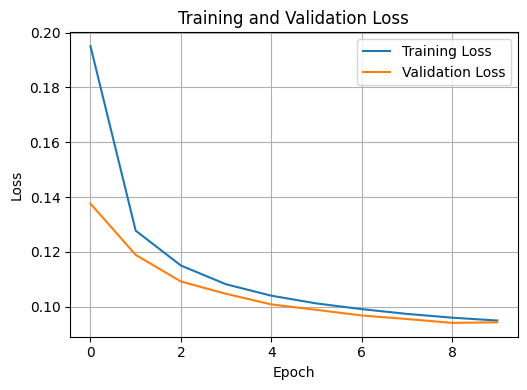

In [ ]:
# ============================================
# 9.2.5 Train the Autoencoder
# ============================================

# Train the autoencoder
history = autoencoder.fit(
    x_train, x_train,  # Input and output are the same
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Plot the training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step


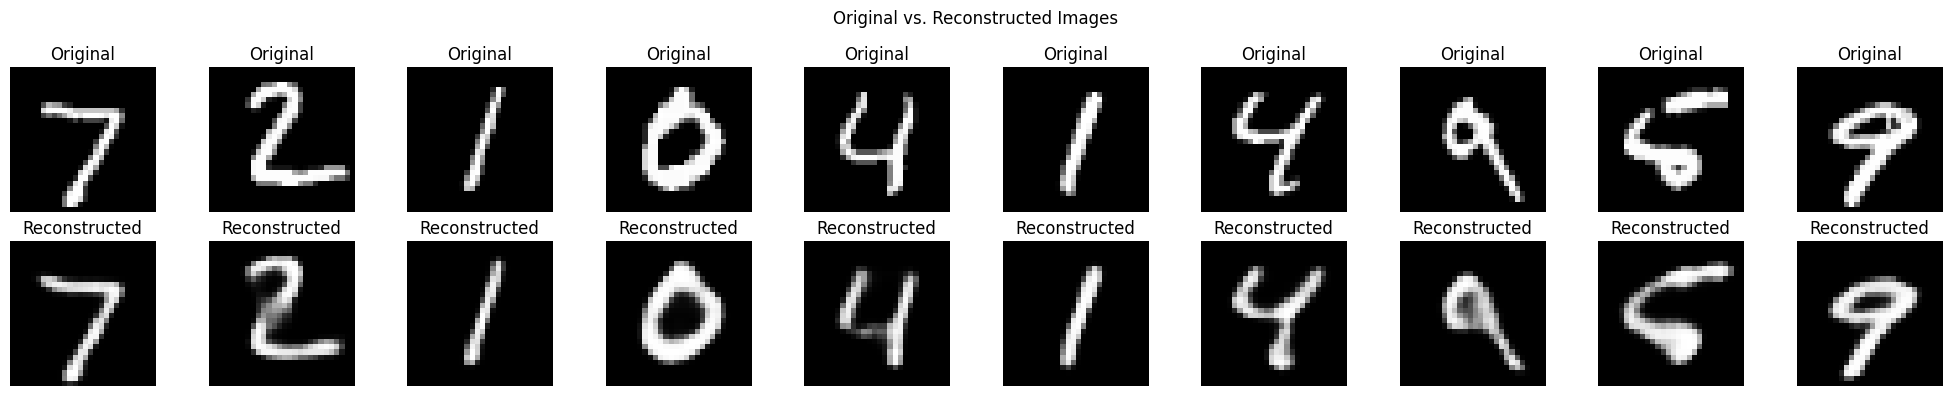

✅ Autoencoder training complete!


In [ ]:
# ============================================
# 9.2.6 Visualize the Reconstructed Images
# ============================================

# Encode and decode some test images
decoded_imgs = autoencoder.predict(x_test[:10])

# Display original and reconstructed images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')

plt.suptitle('Original vs. Reconstructed Images')
plt.tight_layout()
plt.show()

print("✅ Autoencoder training complete!")

In [ ]:
# ============================================
# 9.3.1 Extract Features from the Encoder
# ============================================

# Extract the encoder part of the autoencoder
encoder = Model(input_img, encoded)

# Encode the test images
encoded_imgs = encoder.predict(x_test)

print(f"Shape of encoded images: {encoded_imgs.shape}")

# Flatten for visualization
encoded_flattened = encoded_imgs.reshape(encoded_imgs.shape[0], -1)
print(f"Flattened shape: {encoded_flattened.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Shape of encoded images: (10000, 4, 4, 8)
Flattened shape: (10000, 128)


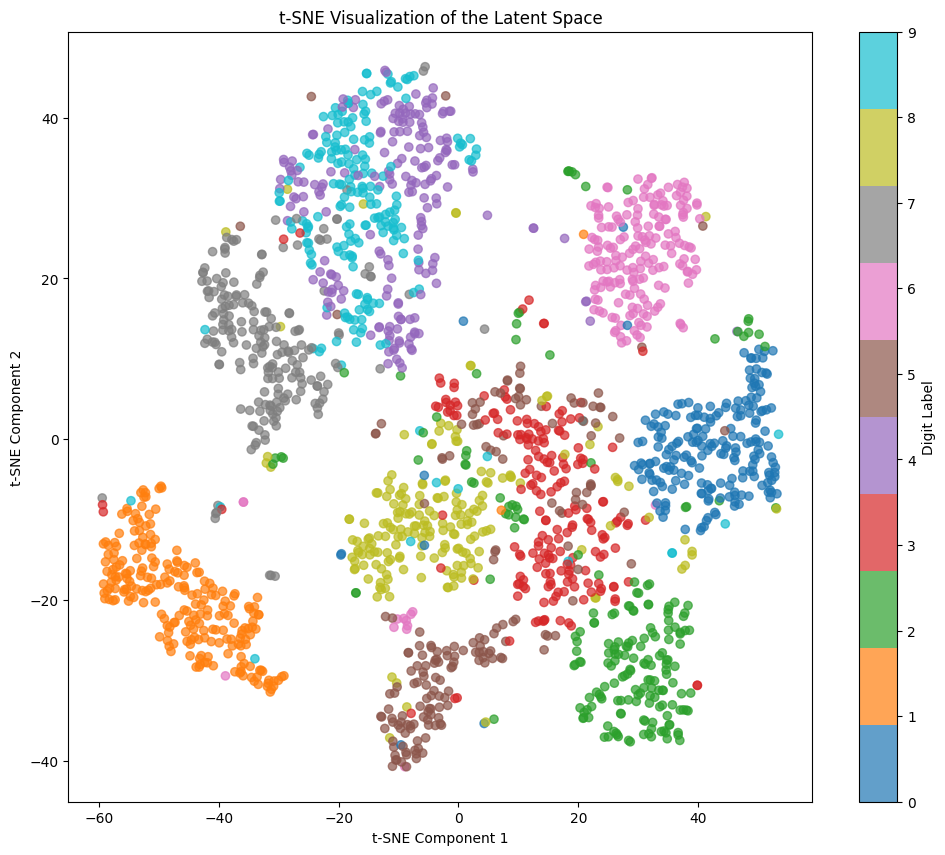

In [ ]:
# ============================================
# 9.3.2 Visualize the Latent Space (Corrected)
# ============================================

from sklearn.manifold import TSNE
import seaborn as sns

# Use only 2000 samples for visualization (to keep it fast)
sample_indices = np.random.choice(len(x_test), 2000, replace=False)
sample_encoded = encoded_flattened[sample_indices]

# Use integer labels directly (y_test is 1D, no argmax needed)
sample_labels = y_test[sample_indices].flatten()

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(sample_encoded)

# Plot the t-SNE results
plt.figure(figsize=(12, 10))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1],
                     c=sample_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Digit Label')
plt.title('t-SNE Visualization of the Latent Space')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

In [ ]:
# ============================================
# 9.3.3 Use Autoencoder Features for Classification (Fixed)
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Prepare training data
train_encoded = encoder.predict(x_train).reshape(x_train.shape[0], -1)
test_encoded = encoder.predict(x_test).reshape(x_test.shape[0], -1)

# Scale the encoded features (improves convergence)
scaler = StandardScaler()
train_encoded_scaled = scaler.fit_transform(train_encoded)
test_encoded_scaled = scaler.transform(test_encoded)

# Train a classifier on the scaled encoded features
clf = LogisticRegression(max_iter=2000, random_state=42)
clf.fit(train_encoded_scaled, y_train)

# Evaluate the classifier
y_pred = clf.predict(test_encoded_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification accuracy on encoded features: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification accuracy on encoded features: 0.9747

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.97      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
# ============================================
# 9.3.4 Compare with Raw Pixel Classification
# ============================================

# Classify using raw pixels
clf_raw = LogisticRegression(max_iter=1000, random_state=42)

# Flatten the raw images
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

clf_raw.fit(x_train_flat, y_train)
y_pred_raw = clf_raw.predict(x_test_flat)
accuracy_raw = accuracy_score(y_test, y_pred_raw)

print(f"Classification accuracy (raw pixels): {accuracy_raw:.4f}")
print(f"Classification accuracy (autoencoder features): {accuracy:.4f}")

Classification accuracy (raw pixels): 0.9259
Classification accuracy (autoencoder features): 0.9747


In [ ]:
# ============================================
# 9.7.4 Feature Extraction Phase
# ============================================

# Load CIFAR-10 as a stand-in for a custom dataset
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Use only a subset for faster training
x_train = x_train[:2000]
y_train = y_train[:2000]
x_test = x_test[:500]
y_test = y_test[:500]

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Resize images to 224x224 for VGG16
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img

def resize_images(images, target_size=(224, 224)):
    resized = []
    for img in images:
        img_pil = array_to_img(img)
        img_resized = img_pil.resize(target_size)
        resized.append(img_to_array(img_resized))
    return np.array(resized)

x_train_resized = resize_images(x_train)
x_test_resized = resize_images(x_test)

print(f"✅ Resized training set: {x_train_resized.shape}")
print(f"✅ Resized test set: {x_test_resized.shape}")

# Load VGG16 without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Create the complete model
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model with frozen base
history_extraction = model.fit(
    x_train_resized, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test_resized, y_test),
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test_resized, y_test, verbose=0)
print(f"Test accuracy after feature extraction: {test_acc:.4f}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1908s 11us/step
✅ Resized training set: (2000, 224, 224, 3)
✅ Resized test set: (500, 224, 224, 3)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 487ms/step - accuracy: 0.4375 - loss: 1.7454 - val_accuracy: 0.5880 - val_loss: 1.1481
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.7255 - loss: 0.7991 - val_accuracy: 0.6460 - val_loss: 0.9904
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 205ms/step - accuracy: 0.8110 - loss: 0.5689 - val_accuracy: 0.6800 - val_loss: 0.9287
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - accuracy: 0.8735 - loss: 0.3957 - val_accuracy: 0.7080 - val_loss: 0.9336
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - accuracy: 0.9075 - loss: 0.3022 - val_accuracy: 0.7100 - val_loss: 0.8449
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - accuracy: 0.9355 - loss: 0.2160 - val_accuracy: 0.7260 - val_loss: 0.8501
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━

In [ ]:
# ============================================
# 9.7.5 Fine-Tuning Phase
# ============================================

# Unfreeze the top layers
base_model.trainable = True

# Choose which layers to unfreeze (from block5 onward)
for layer in base_model.layers:
    if 'block5' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile with a lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Fine-tuning ready.")

# Fine-tune the model
history_finetune = model.fit(
    x_train_resized, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test_resized, y_test),
    verbose=1
)

# Evaluate
test_loss_ft, test_acc_ft = model.evaluate(x_test_resized, y_test, verbose=0)
print(f"Test accuracy after feature extraction: {test_acc:.4f}")
print(f"Test accuracy after fine-tuning: {test_acc_ft:.4f}")
print(f"Improvement: {(test_acc_ft - test_acc)*100:.2f}%")

✅ Fine-tuning ready.
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 293ms/step - accuracy: 0.9980 - loss: 0.0312 - val_accuracy: 0.7380 - val_loss: 1.0109
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 223ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.7400 - val_loss: 1.0709
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.7340 - val_loss: 1.1074
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 233ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.7400 - val_loss: 1.1317
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 236ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.7300 - val_loss: 1.1757
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 240ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.7380 - val_loss: 1.1799
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 246ms/step - accuracy: 1.0000 - loss: 8.5844e-04 - val_accuracy: 0.7340 - val_loss: 1.2145
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 1.0000 